<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter17_DecisionTrees_RandomForest_ver3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 17: Decision Trees and Random Forests

---

🎓 **Course Context**

Prepared for **BIFX-546 – Machine Learning for Bioinformatics**

Instructor: Sarangan Ravichandran, PhD., PMP

---

## 📘 Attribution & Reading Reference

This notebook is based on concepts, structure, and examples from:

> *Data Science from Scratch*, 2nd Edition — Joel Grus, O'Reilly Media, Inc.
> **Relevant Reading: Chapter 17 — Decision Trees**

The material has been **expanded with additional explanations, derivations, scikit-learn comparisons, and exercises** to support instructional use in a Google Colab environment. Any additions beyond the original text are the responsibility of the notebook author.

This notebook is intended for **educational use only** and does not replace the original book.

---

## 🗺️ What We Will Cover

| Section | Topic |
|---|---|
| 1 | What is a Decision Tree? |
| 2 | Entropy — the core math |
| 3 | Information Gain & Partition Entropy |
| 4 | Building a Decision Tree from Scratch (ID3) |
| 5 | Classifying with the Tree |
| 6 | Decision Trees with scikit-learn |
| 7 | Overfitting and Pruning |
| 8 | Random Forests — from scratch |
| 9 | Random Forests with scikit-learn |
| 10 | Regression Trees (ISLP examples) |
| 11 | Exercises |


---
## ⚙️ Environment Setup

We clone the [Data Science from Scratch](https://github.com/joelgrus/data-science-from-scratch) repo so we can import its helper modules throughout the notebook.

In [1]:
# ==== Course setup: safe clone + cd + import path ====
import os
import sys

REPO_URL = "https://github.com/joelgrus/data-science-from-scratch.git"
REPO_DIR = "data-science-from-scratch"

# 1. If we're anywhere inside the repo already, move up to the parent
cwd = os.getcwd()
if REPO_DIR in cwd.split(os.sep):
    parts = cwd.split(os.sep)
    while parts and parts[-1] != REPO_DIR:
        parts.pop()
    parent_dir = os.sep.join(parts[:-1]) or "/"
    os.chdir(parent_dir)
    print(f"Moved to parent directory: {os.getcwd()}")

# 2. Clone only if needed
if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    !git clone {REPO_URL}
else:
    print(f"{REPO_DIR} already exists — skipping clone.")

# 3. cd into the repo
%cd {REPO_DIR}

# 4. Ensure the repo is importable
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())
    print("Added repo to sys.path")

Cloning repo...
Cloning into 'data-science-from-scratch'...
remote: Enumerating objects: 392, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 392 (delta 107), reused 93 (delta 93), pack-reused 247 (from 1)
Receiving objects: 100% (392/392), 762.39 KiB | 4.83 MiB/s, done.
Resolving deltas: 100% (207/207), done.
/content/data-science-from-scratch
Added repo to sys.path


In [2]:
# Install any additional packages we need
!pip install ISLP --quiet
!pip install matplotlib seaborn scikit-learn --quiet

print("All packages ready!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.8 MB/s eta 0:00:00
All packages ready!


---
## 1. What Is a Decision Tree?

A **decision tree** is a flowchart-like model that maps observations about data (features) to conclusions about a target value (class or number). At each internal node, the tree asks a question about one feature; the answer routes us down a branch toward a prediction at a leaf.

https://en.wikipedia.org/wiki/Decision_tree_learning#/media/File:Decision_Tree.jpg

### 🔑 Key Properties

**Pros:**
- Easy to understand and visualize — the logic is completely transparent
- Handles both **numeric** (e.g., age ≥ 30) and **categorical** (e.g., language = Python) features
- Handles missing values gracefully via default predictions
- No need to normalize or scale features

**Cons:**
- Finding the *optimal* tree is NP-hard — we use greedy heuristics instead
- Prone to **overfitting**: a fully grown tree memorizes training data
- Small changes in data can produce very different trees (high variance)

> 💡 To address overfitting, we use **bagging**, **random forests**, and **boosting** — all of which grow multiple trees and combine their predictions.

### Two Flavors of Decision Trees

| Type | Output | Splitting Criterion |
|---|---|---|
| **Classification Tree** | Categorical label | Entropy / Gini impurity |
| **Regression Tree** | Numeric value | Mean Squared Error (MSE) |

In this chapter we implement classification trees using the **ID3 algorithm**, then show regression trees via scikit-learn and the ISLP dataset.

---
## 2. Entropy — The Core Math

To decide *which feature to split on*, we need a measure of **uncertainty** in the data. That measure is **entropy**, borrowed from information theory (Shannon, 1948).

### Definition

Given a dataset $S$ whose points belong to classes $C_1, \ldots, C_n$ with proportions $p_1, \ldots, p_n$:

$$H(S) = -\sum_{i=1}^{n} p_i \log_2 p_i$$

with the convention that $0 \log_2 0 = 0$.

### Intuition

| Situation | Entropy |
|---|---|
| All data in one class (perfectly certain) | $H = 0$ |
| Data split 50/50 between two classes | $H = 1$ bit |
| Data spread evenly across many classes | $H$ is large |

The term $-p \log_2 p$ reaches its maximum at $p = 0.5$ and is 0 at $p = 0$ or $p = 1$:

- $p = 1.0$: $-1 \cdot \log_2 1 = 0$ → we know exactly what class it is
- $p = 0.5$: $-0.5 \cdot \log_2 0.5 = 0.5$ → two such classes give $H = 1$
- $p = 0.25$: $-0.25 \cdot \log_2 0.25 = 0.5$ → four such classes give $H = 2$

**A good split reduces entropy in the resulting subsets.**

# Entropy

To understand entropy, we plot two related curves side by side. The left plot shows -p log₂p — a single term that captures how one class contributes to uncertainty as its probability p varies from 0 to 1. The right plot shows the full binary entropy

H(p) = -p log₂p - (1-p) log₂(1-p),

which sums the contributions of both classes in a two-class problem, where p is the fraction of samples in class 1 and 1-p is the fraction in class 2. Both curves peak at p = 0.5 — the point of maximum uncertainty — and drop to zero at p = 0 and p = 1, where the outcome is completely certain.

# Calculate Shannon's Entropy

H(p) = $\sum_{i}-p_i * log_2(p_i) $


$H(p) = -p·log₂(p)  +  -(1-p)·log₂(1-p)$
```
        ↑                    ↑
   class 1 contribution   class 2 contribution
```

In [3]:
from typing import List, Any
from collections import Counter
import math

def entropy(class_probabilities: List[float]) -> float:
    """
    Given a list of class probabilities, compute the Shannon entropy (in bits).
    H(S) = -sum(p * log2(p)) for p > 0
    """
    return sum(-p * math.log(p, 2)
               for p in class_probabilities
               if p > 0)   # 0 * log(0) is defined as 0 by convention

# Sanity checks
assert entropy([1.0]) == 0,           "Pure node must have entropy 0"
assert entropy([0.5, 0.5]) == 1,      "50/50 split must have entropy 1 bit"
assert 0.81 < entropy([0.25, 0.75]) < 0.82

print("entropy([1.0])      =", entropy([1.0]))          # 0 — perfectly certain
print("entropy([0.5, 0.5]) =", entropy([0.5, 0.5]))    # 1 — maximum for 2 classes
print("entropy([0.25,0.75])=", entropy([0.25, 0.75]))  # ~0.811
print("entropy([0.25]*4)   =", entropy([0.25]*4))       # 2 — uniform over 4 classes

entropy([1.0])      = 0.0
entropy([0.5, 0.5]) = 1.0
entropy([0.25,0.75])= 0.8112781244591328
entropy([0.25]*4)   = 2.0


> 📝 **Note:** When a class has probability $p = 0$, the term $-p \log_2 p$
> is undefined mathematically since $\log_2(0) = -\infty$. However, by
> convention we treat $0 \cdot \log_2(0) = 0$, because a class that **never
> appears** contributes **zero uncertainty** — and the mathematics confirms
> this via the limit $\lim_{p \to 0} -p \log_2 p = 0$.
>
> This is why the code filters out zero probabilities with `if p > 0`.

```
p       log₂(p)      -p · log₂(p)
0.5     -1.0         0.500
0.1     -3.32        0.332
0.01    -6.64        0.066
0.001   -9.97        0.010
0.0001  -13.29       0.001
0.00001 -16.61       0.0002
→ 0     → -∞         → 0  ✅
```

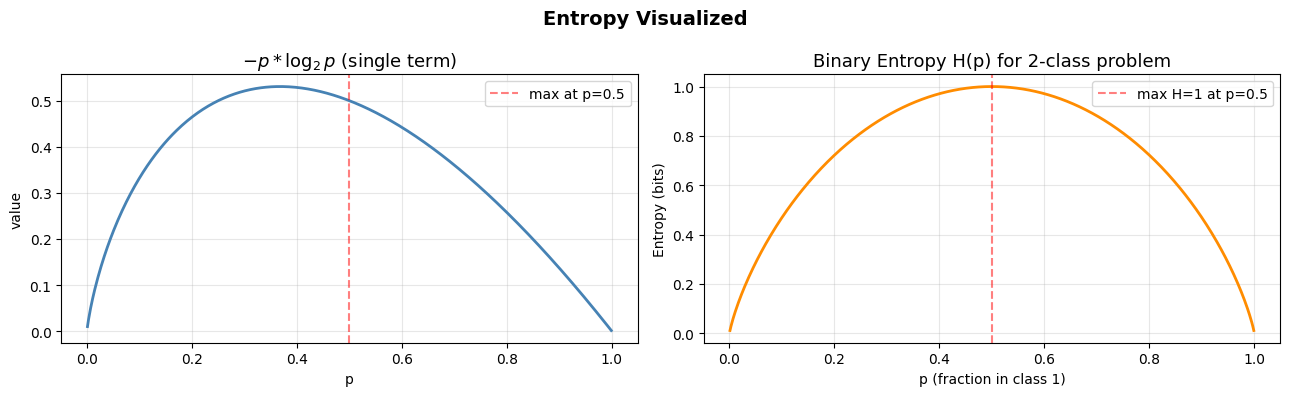

Note: entropy is 0 when p=0 or p=1 (pure), and maximum at p=0.5 (maximum uncertainty).


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Plot -p * log2(p) to build intuition
p_vals = np.linspace(0.001, 0.999, 500)
neg_p_log_p = -p_vals * np.log2(p_vals)

# Also plot full binary entropy H(p) = -p*log2(p) - (1-p)*log2(1-p)
binary_entropy = -p_vals * np.log2(p_vals) - (1 - p_vals) * np.log2(1 - p_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(p_vals, neg_p_log_p, color='steelblue', lw=2)
axes[0].set_title(r'$-p * \log_2 p$ (single term)', fontsize=13)
axes[0].set_xlabel('p'); axes[0].set_ylabel('value')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='max at p=0.5')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(p_vals, binary_entropy, color='darkorange', lw=2)
axes[1].set_title('Binary Entropy H(p) for 2-class problem', fontsize=13)
axes[1].set_xlabel('p (fraction in class 1)'); axes[1].set_ylabel('Entropy (bits)')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='max H=1 at p=0.5')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Entropy Visualized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: entropy is 0 when p=0 or p=1 (pure), and maximum at p=0.5 (maximum uncertainty).")

The Key Insight

H(p) is perfectly symmetric around p = 0.5 because it doesn't matter which class dominates — what matters is how certain you are. Complete certainty in either direction gives H(p) = 0 ✅


### From Raw Labels to Probabilities

In practice, our data has *labels* (not probabilities). We use `Counter` to turn labels into counts, then normalize by the total number of points.

```
labels = [3, 4, 4, 4]
Counter(labels) → {4: 3, 3: 1}
total = 4
probabilities = [3/4, 1/4] = [0.75, 0.25]
```

Note: **Entropy doesn't care *which* class has which probability — only the distribution matters.**

In [5]:
l = [3, 4, 4, 4]
t = len(l)
print(t)
lc = Counter(l)
print(lc)
for i in lc.values():
  print(i, i/t)

4
Counter({4: 3, 3: 1})
1 0.25
3 0.75


In [6]:
def class_probabilities(labels: List[Any]) -> List[float]:
    """Convert a list of labels into a list of class probabilities."""
    total_count = len(labels)
    return [count / total_count
            for count in Counter(labels).values()]

def data_entropy(labels: List[Any]) -> float:
    """Compute entropy of a labeled dataset."""
    return entropy(class_probabilities(labels))

# Verification
assert data_entropy(['a']) == 0                             # pure — only one label
assert data_entropy([True, False]) == 1                     # perfectly uncertain
assert data_entropy([3, 4, 4, 4]) == entropy([0.25, 0.75]) # 1 of 4 is class 3

print("data_entropy(['a'])         =", data_entropy(['a']))
print("data_entropy([True, False]) =", data_entropy([True, False]))
print("data_entropy([3,4,4,4])     =", data_entropy([3, 4, 4, 4]))

# Walk through the Counter step
d = Counter([3, 4, 4, 4])
print("\nCounter([3,4,4,4])       :", dict(d))
print("class_probabilities(...)  :", class_probabilities([3, 4, 4, 4]))

data_entropy(['a'])         = 0.0
data_entropy([True, False]) = 1.0
data_entropy([3,4,4,4])     = 0.8112781244591328

Counter([3,4,4,4])       : {3: 1, 4: 3}
class_probabilities(...)  : [0.25, 0.75]


---
## 3. Information Gain and Partition Entropy

A decision tree splits the data at each node by asking a question. The best question is the one that **reduces uncertainty the most**.

### Partition Entropy

If we split dataset $S$ into subsets $S_1, \ldots, S_m$ (of sizes $q_1, \ldots, q_m$ as fractions of $S$), the entropy *after* the split is the **weighted average** of subset entropies:

$$H_{split} = \sum_{j=1}^{m} q_j \cdot H(S_j)$$

### Information Gain

$$\text{InformationGain} = H(S) - H_{split}$$

We want to **maximize information gain** — equivalently, **minimize partition entropy**.

> ⚠️ **Overfitting warning:** An attribute with many distinct values (like a Social Security Number or user ID) will produce many tiny subsets, each with near-zero entropy — giving artificially high information gain. This perfectly fits training data but generalizes terribly. Always avoid or bucket high-cardinality attributes.

In [7]:
from typing import Dict, TypeVar
from collections import defaultdict

T = TypeVar('T')  # generic input type

def partition_entropy(subsets: List[List[Any]]) -> float:
    """
    Returns the weighted-average entropy after partitioning the data.
    subsets: a list of label lists, one per partition.
    subsets = [
       [True, True, True],    # ← inner List[Any] — Branch 1 labels
       [False],               # ← inner List[Any] — Branch 2 labels
       [True, False, True],   # ← inner List[Any] — Branch 3 labels
    ]
    """
    total_count = sum(len(subset) for subset in subsets)
    # remove
    # print("total_count", total_count)
    # remove
    # weighted sum
    return sum(data_entropy(subset) * len(subset) / total_count
               for subset in subsets)

# Example: splitting [T, T, T, F] into [T, T, T] and [F]
before = data_entropy([True, True, True, False])
after  = partition_entropy([[True, True, True], [False]])

print(f"Entropy before split : {before:.4f}")
print(f"Entropy after split  : {after:.4f}")
print(f"Information gain     : {before - after:.4f}")
print()

# Compare a good vs. bad split
labels = [True, True, False, True, False, False, True, True]
print("Original entropy:", round(data_entropy(labels), 4))

# Good split: separates Trues from Falses cleanly
good_split = [[True, True, True, True, True], [False, False, False]]
print("Good split entropy: ", round(partition_entropy(good_split), 4))

# Bad split: doesn't help at all
bad_split  = [[True, False, True, False], [True, False, True, True]]
print("Bad split entropy:  ", round(partition_entropy(bad_split), 4))

Entropy before split : 0.8113
Entropy after split  : 0.0000
Information gain     : 0.8113

Original entropy: 0.9544
Good split entropy:  0.0
Bad split entropy:   0.9056


```
          [T, T, T, F]          ← Parent node (before split)
         H = 0.8113 bits
              |
         Ask a Question
              |
         /         \
   [T, T, T]      [F]          ← Two branches (after split)
   H = 0.0         H = 0.0
```

# Good Split
```
[T, T, T, T]  → H = 0.0  (pure!)
[F, F, F]     → H = 0.0  (pure!)
Weighted H    = 0.0
Gain          = 0.9544 - 0.0 = 0.9544  ✅ Maximum!
```

# Bad Split

```
[T, F, T, F]  → H = 1.0  (50/50 — worst!)
[T, F, T]     → H = 0.918
Weighted H    = high
Gain          = very low  ❌ Useless!
```

# Complete Decision Tree Building Process

1. Calculate H of parent node

2. Try splitting on every possible question/feature

3. Calculate weighted H after each split.
4. Calculate Information Gain for each split
   Gain = H(parent) - Weighted H(after split)
5. Pick the split with HIGHEST gain
6. Repeat for each branch until:
   - Branch is pure (H = 0) ✅
   - Or no more features to split on

# Multiclass Example
```
Classes: Cat, Dog, Bird

Parent Node: [Cat, Cat, Dog, Dog, Bird, Bird, Cat, Dog]
              8 samples, 3 classes
```

# calculate H (parent)

$$ \text{H(parent)} = \sum_{i} -p_{i} \times log_{2}(p_i) $$

```
P(Cat)  = 3/8 = 0.375
P(Dog)  = 3/8 = 0.375
P(Bird) = 2/8 = 0.250

H(parent) = -0.375×log₂(0.375)
           - 0.375×log₂(0.375)
           - 0.250×log₂(0.250)
          = 1.561 bits
```

# Ask a question: Does it have feathers?

```
Parent: [Cat, Cat, Dog, Dog, Bird, Bird, Cat, Dog]
                    |
         "Has Feathers?"
          /              \
        NO                YES
[Cat,Cat,Dog,Dog,Cat,Dog] [Bird, Bird]
   6 samples                2 samples
   Still multiclass!        Pure! ✅
```

# Step1 for each branch

```
Branch 1 (No feathers):
P(Cat) = 3/6 = 0.5
P(Dog) = 3/6 = 0.5
P(Bird)= 0/6 = 0.0

H(B1) = -0.5×log₂(0.5) - 0.5×log₂(0.5)
       = 1.0 bits  ← still impure!

Branch 2 (Has feathers):
P(Bird) = 2/2 = 1.0
P(Cat)  = 0.0
P(Dog)  = 0.0

H(B2) = -1.0×log₂(1.0)
       = 0.0 bits  ← pure! ✅
```

# Step2: Weighted Average

```
Weighted H = H(B1) × (6/8)  +  H(B2) × (2/8)
           = 1.0   × 0.75   +  0.0   × 0.25
           = 0.75 bits
```

# Step 3: Information Gain

```
Gain = H(parent) - Weighted H(branches)
     = 1.561     - 0.75
     = 0.811 bits  ✅ meaningful split!
```

# What Happens Next?
Branch 2 is pure — no more splitting needed ✅
Branch 1 is still impure — ask another question!

```
Branch 1: [Cat, Cat, Dog, Dog, Cat, Dog]
                    |
          "Does it bark?"
           /           \
         NO             YES
   [Cat,Cat,Cat]      [Dog,Dog,Dog]
      Pure! ✅           Pure! ✅
      H = 0.0            H = 0.0

```

# Complete Tree

```
"Has Feathers?"
├── YES → Bird ✅
└── NO  → "Does it bark?"
          ├── YES → Dog ✅
          └── NO  → Cat ✅
```

---
## 4. Building a Decision Tree from Scratch (ID3 Algorithm)

*(Note: ID3 — Iterative Dichotomiser 3Invented by Ross Quinlan in 1986. It is the classic algorithm for building a Decision Tree.)*

### The Problem: Predicting Successful Interviews

DataSciencester's VP of Talent wants to predict which job candidates will interview well. He provides a dataset of 14 candidates described by four features:

| Feature | Values |
|---|---|
| `level` | Junior, Mid, Senior |
| `lang` | Java, Python, R |
| `tweets` | True, False |
| `phd` | True, False |

| Outcome | Values |
|---|---|
| `did_well` | True, False (target) |

### The ID3 Algorithm (Greedy)

At each node:
1. If all data has the **same label** → make a Leaf node with that label. Stop.
2. If **no attributes remain** → make a Leaf node with the majority label. Stop.
3. Otherwise, try all attributes. Choose the one with **lowest partition entropy** (highest information gain).
4. Split the data by that attribute, create a Split node, and **recurse** on each subset with the remaining attributes.

This is a *greedy* algorithm — it picks the locally best attribute at each step, not the globally optimal tree.

Before we go any further, let us understand some basic Python concepts that will help us code the next section.

# `NamedTuple`

NamedTuple is a class built into Python's typing module that lets you create tuples with named fields

# Why `NamedTuple`

```python
# Regular tuple — access by INDEX only
candidate = ("Senior", "Python", True, False, True)
candidate[0]   # "Senior"  ← what is index 0? Hard to remember!
candidate[2]   # True      ← is this tweets or phd??
```

A NamedTuple gives each position a name:

```python
# NamedTuple — access by NAME
candidate.level    # "Senior"  ← clear!
candidate.tweets   # True      ← clear!
candidate.phd      # False     ← clear!
```

# Inherit from `NamedTuple` class

```python
class Candidate(NamedTuple):  # ← inheriting from NamedTuple
    level:    str
    lang:     str
    tweets:   bool
    phd:      bool
    did_well: Optional[bool] = None
```

# Optional

```python
did_well: Optional[bool] = None

# Optional[bool] simply means the field can be:

True    # candidate did well
False   # candidate did not do well
None    # we don't know yet — unlabeled!

did_well: Union[bool, None] = None
```

# What is `Union`

```python
Union[bool, None]   # can be bool OR None
Union[int, str]     # can be int OR str
Union[Leaf, Split]  # can be Leaf OR Split ← your DecisionTree!
```

# Putting it all-together
```python
class Whatever(NamedTuple):
    a: str
    b: str
    c: bool
    d: Optional[bool] = None

# Create an instance:
A = Whatever("Sam", "Lives in", True, None)

# Access by NAME:
print(A.a)   # "Sam"
print(A.b)   # "Lives in DC"
print(A.c)   # True
print(A.d)   # None

# Also still accessible by INDEX (it's still a tuple!):
print(A[0])  # "Sam"
print(A[1])  # "Lives in DC"

# Note
# Optional[bool] means ONE value that is either:
d = True    # ✅ valid
d = False   # ✅ valid
d = None    # ✅ valid

# NOT a list:
d = [True, False]  # ❌ wrong — not what Optional means!

```

In [8]:
from typing import NamedTuple, Optional, Union

class Candidate(NamedTuple):
    level:    str
    lang:     str
    tweets:   bool
    phd:      bool
    did_well: Optional[bool] = None  # allows unlabeled data

#            level      lang      tweets  phd    did_well
inputs = [
    Candidate('Senior',  'Java',   False,  False, False),
    Candidate('Senior',  'Java',   False,  True,  False),
    Candidate('Mid',     'Python', False,  False, True),
    Candidate('Junior',  'Python', False,  False, True),
    Candidate('Junior',  'R',      True,   False, True),
    Candidate('Junior',  'R',      True,   True,  False),
    Candidate('Mid',     'R',      True,   True,  True),
    Candidate('Senior',  'Python', False,  False, False),
    Candidate('Senior',  'R',      True,   False, True),
    Candidate('Junior',  'Python', True,   False, True),
    Candidate('Senior',  'Python', True,   True,  True),
    Candidate('Mid',     'Python', False,  True,  True),
    Candidate('Mid',     'Java',   True,   False, True),
    Candidate('Junior',  'Python', False,  True,  False),
]

# Quick summary
total = len(inputs)
positives = sum(1 for c in inputs if c.did_well)
print(f"Dataset: {total} candidates, {positives} did well ({positives/total:.0%}), {total-positives} did not")

Dataset: 14 candidates, 9 did well (64%), 5 did not


In [9]:
for inp in inputs:
  print(inp)

Candidate(level='Senior', lang='Java', tweets=False, phd=False, did_well=False)
Candidate(level='Senior', lang='Java', tweets=False, phd=True, did_well=False)
Candidate(level='Mid', lang='Python', tweets=False, phd=False, did_well=True)
Candidate(level='Junior', lang='Python', tweets=False, phd=False, did_well=True)
Candidate(level='Junior', lang='R', tweets=True, phd=False, did_well=True)
Candidate(level='Junior', lang='R', tweets=True, phd=True, did_well=False)
Candidate(level='Mid', lang='R', tweets=True, phd=True, did_well=True)
Candidate(level='Senior', lang='Python', tweets=False, phd=False, did_well=False)
Candidate(level='Senior', lang='R', tweets=True, phd=False, did_well=True)
Candidate(level='Junior', lang='Python', tweets=True, phd=False, did_well=True)
Candidate(level='Senior', lang='Python', tweets=True, phd=True, did_well=True)
Candidate(level='Mid', lang='Python', tweets=False, phd=True, did_well=True)
Candidate(level='Mid', lang='Java', tweets=True, phd=False, did_well

In [10]:
print(inputs[0].lang)
inputs[0].did_well

Java


False

Here are two example candidates

# Labeled candidate — we know the outcome
```
c1 = Candidate(
    level="Junior",
    lang="Python",
    tweets=True,
    phd=False,
    did_well=True
)
```

# Unlabeled candidate — outcome unknown
```
c2 = Candidate(
    level="Senior",
    lang="Java",
    tweets=False,
    phd=True,
    did_well=None  # or simply omit it
)
```

# Some Python Code to Familiarize before moving to the next section

# 1. `getattr()` Dynamic Attribute Access

```python
Candidate(
    level="Senior",
    lang="Java",
    tweets=False,
    phd=True,
    did_well=None  # or simply omit it
)
```

```python
# Instead of:
candidate.level

# getattr does it dynamically:
getattr(candidate, "level")  # same result!

# Why useful?
attribute = "level"  # can change at runtime
getattr(candidate, attribute)  # works for ANY attribute name
```

In [11]:
Sam = Candidate(
    level="Senior",
    lang="Java",
    tweets=False,
    phd=True,
    did_well=None  # or simply omit it
)
Sam.level

'Senior'

In [12]:
getattr(Sam,"level")

'Senior'

In [13]:
for l in ["level", "lang"]:
  print(getattr(Sam, l))

Senior
Java


# 2. `defaultdict` Dictionary with Default Values

```python
from collections import defaultdict

# Regular dict — crashes:
d = {}
d["Junior"].append("something")  # ❌ KeyError!

# defaultdict — safe:
d = defaultdict(list)
d["Junior"].append("something")  # ✅ auto creates []
```


# 3. `TypeVar` — Generic Type Placeholder

```python
from typing import TypeVar

T = TypeVar('T')  # T is a placeholder for ANY TYPE

# When called with Candidates → T becomes Candidate
# When called with Students   → T becomes Student
```

# 4. Dictionary `.values`

```python
d = {
    "Junior": [c1, c2],
    "Senior": [c3, c4]
}

d.values()  # → [[c1, c2], [c3, c4]]
#               ↑
#          just the lists, not the keys
```

# 5. Nested List Comprehension

```python
# This is used inside partition_entropy_by:
labels = [[getattr(inp, label_attribute) for inp in partition]
           for partition in partitions.values()]

# Break it down:
# Outer loop:
for partition in partitions.values()
# → goes through each branch [c1,c2], [c3,c4]

# Inner loop:
for inp in partition
# → goes through each candidate in branch

# Result:
labels = [
    [True, False],   # labels from branch 1
    [True, True],    # labels from branch 2
]
```


# 6.  `List[Any]` vs `List[T]`

```python
# List[Any] — accepts ANY type, no consistency needed:
def fn(inputs: List[Any])  # items can be mixed types

# List[T] — accepts ANY type, but ALL items must be SAME type:
def fn(inputs: List[T])    # items must all be same type
```

# Code Explanation

```python
# Example: partition_by(candidates, "level")
# Goes through each candidate and groups by level:

inputs = [
    Candidate("Junior", "Python", True,  False, True),
    Candidate("Junior", "Java",   False, False, False),
    Candidate("Senior", "Python", True,  True,  True),
    Candidate("Senior", "Java",   False, False, False),
    Candidate("Mid",    "Python", False, False, True),
]

# Result:
{
    "Junior": [Candidate(...), Candidate(...)],
    "Senior": [Candidate(...), Candidate(...)],
    "Mid":    [Candidate(...)]
}
```

In [14]:
def partition_by(inputs: List[T], attribute: str) -> Dict[Any, List[T]]:
    """Group inputs into a dict keyed by the given attribute's value."""
    partitions: Dict[Any, List[T]] = defaultdict(list)
    for inp in inputs: # loop through each candidate
        key = getattr(inp, attribute) # get value of the feature
                                      # e.g. getattr(candidate, "level") = "Junior"
        partitions[key].append(inp) # add candidate to the bucket
    return partitions

def partition_entropy_by(inputs: List[Any],
                         attribute: str,
                         label_attribute: str) -> float:
    """Compute the partition entropy when splitting inputs by attribute."""
    partitions = partition_by(inputs, attribute)
    labels = [[getattr(inp, label_attribute) for inp in partition]
              for partition in partitions.values()]
    return partition_entropy(labels)

# Step 1: find the best first split
print("Partition entropy for each attribute (lower = better split):")
print("-" * 45)
for key in ['level', 'lang', 'tweets', 'phd']:
    pe = partition_entropy_by(inputs, key, 'did_well')
    marker = "  ← best" if key == 'level' else ""
    print(f"  {key:8s}: {pe:.4f}{marker}")

# Verify book values
assert 0.69 < partition_entropy_by(inputs, 'level',  'did_well') < 0.70
assert 0.86 < partition_entropy_by(inputs, 'lang',   'did_well') < 0.87
assert 0.78 < partition_entropy_by(inputs, 'tweets', 'did_well') < 0.79
assert 0.89 < partition_entropy_by(inputs, 'phd',    'did_well') < 0.90
print("\nAll assertions passed ✓")

Partition entropy for each attribute (lower = better split):
---------------------------------------------
  level   : 0.6935  ← best
  lang    : 0.8601
  tweets  : 0.7885
  phd     : 0.8922

All assertions passed ✓


# Here is a complete picture so far

```
partition_by()
    ↓
Groups candidates by feature value
    {"Junior": [...], "Senior": [...], "Mid": [...]}
    ↓
partition_entropy_by()
    ↓
Extracts labels from each group
    [[T,F,F], [T,F,T], [T,T]]
    ↓
partition_entropy()
    ↓
Calculates weighted average entropy
    0.6935
    ↓
Try all features → pick lowest entropy
    "level" wins! ← best first split
```

# Detailed Explanation using a smaller dataset

```python
inputs = [
    Candidate(level="Junior", lang="Python", tweets=True,  phd=False, did_well=True),
    Candidate(level="Junior", lang="Java",   tweets=False, phd=False, did_well=False),
    Candidate(level="Senior", lang="Python", tweets=True,  phd=True,  did_well=True),
]
```

# calling `partition_by(inputs, levels)`

```python
partitions = defaultdict(list)  # start with empty dict {}

# ── Loop iteration 1 ──
inp = Candidate("Junior", "Python", True, False, True)
key = getattr(inp, "level")   # → "Junior"
partitions["Junior"].append(inp)

# partitions so far:
# {"Junior": [Candidate("Junior","Python",True,False,True)]}

# ── Loop iteration 2 ──
inp = Candidate("Junior", "Java", False, False, False)
key = getattr(inp, "level")   # → "Junior"
partitions["Junior"].append(inp)

# partitions so far:
# {"Junior": [Candidate("Junior","Python",True,False,True),
#             Candidate("Junior","Java",False,False,False)]}

# ── Loop iteration 3 ──
inp = Candidate("Senior", "Python", True, True, True)
key = getattr(inp, "level")   # → "Senior"
partitions["Senior"].append(inp)

# Final partitions:
# {
#   "Junior": [Candidate("Junior","Python",True,False,True),
#              Candidate("Junior","Java",False,False,False)],
#   "Senior": [Candidate("Senior","Python",True,True,True)]
# }
```

## Then `partition_entropy_by(inputs, "level", "did_well")`

```python
# Step 1 — partition_by groups them:
partitions = {
    "Junior": [Candidate(...True), Candidate(...False)],
    "Senior": [Candidate(...True)]
}

# Step 2 — extract did_well labels only:
labels = [
    [True, False],   # ← Junior branch labels
    [True]           # ← Senior branch labels
]

# Step 3 — weighted entropy:
# H([True, False]) = 1.0   weight = 2/3
# H([True])        = 0.0   weight = 1/3

# partition_entropy = 1.0 × 2/3  +  0.0 × 1/3
#                  = 0.667
```


# Overall

```python
3 candidates split by "level"
      ↓
Junior branch → [True, False] → H = 1.0 (mixed!)
Senior branch → [True]        → H = 0.0 (pure!)
      ↓
Weighted entropy = 0.667
      ↓
Try other features and compare — pick lowest! ✅
```

In [15]:
# Step 2: drill into Senior and Junior subgroups
print("=== Senior candidates — next best split ===")
senior_inputs = [inp for inp in inputs if inp.level == 'Senior']
for key in ['lang', 'tweets', 'phd']:
    pe = partition_entropy_by(senior_inputs, key, 'did_well')
    marker = "  ← best" if key == 'tweets' else ""
    print(f"  {key:8s}: {pe:.4f}{marker}")

assert 0.0 == partition_entropy_by(senior_inputs, 'tweets', 'did_well')
print("  → tweets gives 0 entropy: Senior + tweets=True always did well, False always didn't")

print()
print("=== Junior candidates — next best split ===")
junior_inputs = [inp for inp in inputs if inp.level == 'Junior']
for key in ['lang', 'tweets', 'phd']:
    pe = partition_entropy_by(junior_inputs, key, 'did_well')
    marker = "  ← best" if key == 'phd' else ""
    print(f"  {key:8s}: {pe:.4f}{marker}")
print("  → phd gives 0 entropy: Junior + phd=False always did well, True always didn't")

print()
print("=== Mid candidates ===")
mid_inputs = [inp for inp in inputs if inp.level == 'Mid']
mid_labels = [inp.did_well for inp in mid_inputs]
print(f"  Labels: {mid_labels}")
print(f"  Entropy: {data_entropy(mid_labels):.4f}  → pure True, make a Leaf(True)")

=== Senior candidates — next best split ===
  lang    : 0.4000
  tweets  : 0.0000  ← best
  phd     : 0.9510
  → tweets gives 0 entropy: Senior + tweets=True always did well, False always didn't

=== Junior candidates — next best split ===
  lang    : 0.9510
  tweets  : 0.9510
  phd     : 0.0000  ← best
  → phd gives 0 entropy: Junior + phd=False always did well, True always didn't

=== Mid candidates ===
  Labels: [True, True, True, True]
  Entropy: 0.0000  → pure True, make a Leaf(True)


### Tree Representation

We represent our tree as either:
- A **`Leaf`** — stores a single predicted value
- A **`Split`** — stores which attribute to test, a dict of subtrees (one per possible value), and a default prediction for unseen values

```
DecisionTree = Leaf(value) | Split(attribute, subtrees_dict, default_value)
```

In [16]:
class Leaf(NamedTuple):
    value: Any

class Split(NamedTuple):
    attribute:     str
    subtrees:      dict
    default_value: Any = None

DecisionTree = Union[Leaf, Split]

# Manual construction of the hiring tree to match the diagram
hiring_tree = Split('level', {
    'Junior': Split('phd', {
        False: Leaf(True),
        True:  Leaf(False)
    }),
    'Mid':    Leaf(True),
    'Senior': Split('tweets', {
        False: Leaf(False),
        True:  Leaf(True)
    })
})

print("Manually constructed hiring tree:")
print(hiring_tree)

Manually constructed hiring tree:
Split(attribute='level', subtrees={'Junior': Split(attribute='phd', subtrees={False: Leaf(value=True), True: Leaf(value=False)}, default_value=None), 'Mid': Leaf(value=True), 'Senior': Split(attribute='tweets', subtrees={False: Leaf(value=False), True: Leaf(value=True)}, default_value=None)}, default_value=None)


---
## 5. Classifying with the Tree

Classification is a recursive traversal:
1. If we reach a **Leaf** → return its value.
2. Otherwise, look up the input's value for `tree.attribute`, follow that branch, and recurse.
3. If the value isn't in the subtree dict (unseen category), return `default_value`.

In [17]:
def classify(tree: DecisionTree, input: Any) -> Any:
    """Classify an input by traversing the decision tree."""
    if isinstance(tree, Leaf):
        return tree.value

    subtree_key = getattr(input, tree.attribute)

    if subtree_key not in tree.subtrees:
        return tree.default_value   # unseen value → use default

    return classify(tree.subtrees[subtree_key], input)


# Test on known examples from the dataset
test_cases = [
    (Candidate("Junior", "Java",   True,  False), True,  "Junior, no PhD"),
    (Candidate("Junior", "Java",   True,  True),  False, "Junior, with PhD"),
    (Candidate("Mid",    "Python", False, False), True,  "Mid level"),
    (Candidate("Senior", "Python", True,  False), True,  "Senior, tweets"),
    (Candidate("Senior", "R",      False, True),  False, "Senior, no tweets"),
    (Candidate("Intern", "Java",   True,  True),  True,  "Intern (unseen level) → default=True"),
]

print(f"{'Description':<35} {'Expected':>8} {'Got':>8} {'✓/✗':>4}")
print("-" * 60)
for candidate, expected, desc in test_cases:
    prediction = classify(hiring_tree, candidate)
    status = "✓" if prediction == expected else "✗"
    print(f"{desc:<35} {str(expected):>8} {str(prediction):>8} {status:>4}")

Description                         Expected      Got  ✓/✗
------------------------------------------------------------
Junior, no PhD                          True     True    ✓
Junior, with PhD                       False    False    ✓
Mid level                               True     True    ✓
Senior, tweets                          True     True    ✓
Senior, no tweets                      False    False    ✓
Intern (unseen level) → default=True     True     None    ✗


In [18]:
def build_tree_id3(inputs: List[Any],
                   split_attributes: List[str],
                   target_attribute: str) -> DecisionTree:
    """
    Build a decision tree using the ID3 algorithm.

    Parameters
    ----------
    inputs            : list of NamedTuples (training examples)
    split_attributes  : list of attribute names to consider splitting on
    target_attribute  : the attribute we are trying to predict

    Returns
    -------
    A DecisionTree (either Leaf or Split)
    """
    # Count occurrences of each target label
    label_counts = Counter(getattr(inp, target_attribute) for inp in inputs)
    most_common_label = label_counts.most_common(1)[0][0]

    # Base case 1: all labels are the same → pure leaf
    if len(label_counts) == 1:
        return Leaf(most_common_label)

    # Base case 2: no attributes left → majority vote leaf
    if not split_attributes:
        return Leaf(most_common_label)

    # Recursive case: find the attribute with lowest partition entropy
    def split_entropy(attribute: str) -> float:
        return partition_entropy_by(inputs, attribute, target_attribute)

    best_attribute = min(split_attributes, key=split_entropy)
    partitions     = partition_by(inputs, best_attribute)
    new_attributes = [a for a in split_attributes if a != best_attribute]

    # Recursively build a subtree for each value of best_attribute
    subtrees = {
        attr_value: build_tree_id3(subset, new_attributes, target_attribute)
        for attr_value, subset in partitions.items()
    }

    return Split(best_attribute, subtrees, default_value=most_common_label)


# Build the tree from our hiring data
tree = build_tree_id3(inputs,
                      split_attributes=['level', 'lang', 'tweets', 'phd'],
                      target_attribute='did_well')

print("Built tree root:", tree.attribute, "(split on this first)")

# Verify predictions on training data
assert classify(tree, Candidate("Junior", "Java",   True, False)) == True
assert classify(tree, Candidate("Junior", "Java",   True, True))  == False
assert classify(tree, Candidate("Intern", "Java",   True, True))  == True   # default
print("All assertions passed ✓")

# Show full training accuracy
correct = sum(1 for inp in inputs if classify(tree, inp) == inp.did_well)
print(f"\nTraining accuracy: {correct}/{len(inputs)} = {correct/len(inputs):.0%}")
print("(100% on training data — a sign we might be overfitting!)")

Built tree root: level (split on this first)
All assertions passed ✓

Training accuracy: 14/14 = 100%
(100% on training data — a sign we might be overfitting!)


### How the Functions Relate

```
TRAINING (build_tree_id3)
  ├── partition_entropy_by(inputs, attribute, target)
  │     ├── partition_by(inputs, attribute)   → groups inputs
  │     └── partition_entropy(label_lists)
  │           └── data_entropy(labels)
  │                 ├── class_probabilities(labels)
  │                 └── entropy(probabilities)
  └── recursive calls → Leaf or Split nodes

PREDICTION (classify)
  └── traverse Split/Leaf nodes using getattr(input, attribute)
```

---
## 6. Decision Trees with scikit-learn

Now we'll replicate the same classification task using scikit-learn's `DecisionTreeClassifier`, which uses the **Gini impurity** criterion by default (or entropy, which matches our from-scratch version).

### Gini Impurity vs. Entropy




In [19]:
from IPython.display import display, HTML

html = """
<table style="border-collapse: collapse; width: 100%; font-family: sans-serif; font-size: 14px;">
  <thead>
    <tr style="background-color: #4A90D9; color: white;">
      <th style="padding: 10px; border: 1px solid #ddd; width: 15%;">Criterion</th>
      <th style="padding: 10px; border: 1px solid #ddd; width: 45%;">Formula</th>
      <th style="padding: 10px; border: 1px solid #ddd; width: 40%;">Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;"><b>Entropy</b></td>
      <td style="padding: 10px; border: 1px solid #ddd; white-space: nowrap;">
        H = &minus;&sum; p&#x1D456; log&#x2082; p&#x1D456;
      </td>
      <td style="padding: 10px; border: 1px solid #ddd;">
        From information theory; our ID3 approach.<br>
        Range: [0, log&#x2082;n] &nbsp;|&nbsp; 0 = pure
      </td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;"><b>Gini</b></td>
      <td style="padding: 10px; border: 1px solid #ddd; white-space: nowrap;">
        G = 1 &minus; &sum; p&#x1D456;&sup2;
      </td>
      <td style="padding: 10px; border: 1px solid #ddd;">
        Faster to compute; often similar results.<br>
        Range: [0, 1) &nbsp;|&nbsp; 0 = pure
      </td>
    </tr>
  </tbody>
</table>
"""

display(HTML(html))

Criterion,Formula,Notes
Entropy,H = −∑ p𝑖 log₂ p𝑖,"From information theory; our ID3 approach. Range: [0, log₂n] | 0 = pure"
Gini,G = 1 − ∑ p𝑖²,"Faster to compute; often similar results. Range: [0, 1) | 0 = pure"


Both reach 0 for pure nodes and are maximized when classes are equally distributed.

In [20]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Convert our NamedTuple data to a DataFrame
df = pd.DataFrame(inputs, columns=['level', 'lang', 'tweets', 'phd', 'did_well'])
print("Dataset:")
# print(df.to_string(index=False))

Dataset:


In [21]:
df

,level,lang,tweets,phd,did_well
0,Senior,Java,False,False,False
1,Senior,Java,False,True,False
2,Mid,Python,False,False,True
3,Junior,Python,False,False,True
4,Junior,R,True,False,True
5,Junior,R,True,True,False
6,Mid,R,True,True,True
7,Senior,Python,False,False,False
8,Senior,R,True,False,True
9,Junior,Python,True,False,True


In [22]:
df.shape

(14, 5)

In [23]:
df.did_well.value_counts()

,count
did_well,
True,9
False,5


In [24]:
# Encode categoricals for sklearn (it requires numeric input)
df_enc = df.copy()
le = {}

for col in ['level', 'lang']:
    le[col] = LabelEncoder()
    df_enc[col] = le[col].fit_transform(df[col])

for col in ['tweets', 'phd', 'did_well']:
    df_enc[col] = df_enc[col].astype(int)

df_enc

,level,lang,tweets,phd,did_well
0,2,0,0,0,0
1,2,0,0,1,0
2,1,1,0,0,1
3,0,1,0,0,1
4,0,2,1,0,1
5,0,2,1,1,0
6,1,2,1,1,1
7,2,1,0,0,0
8,2,2,1,0,1
9,0,1,1,0,1


In [25]:
X = df_enc[['level', 'lang', 'tweets', 'phd']]
y = df_enc['did_well']

In [26]:
X.head()

,level,lang,tweets,phd
0,2,0,0,0
1,2,0,0,1
2,1,1,0,0
3,0,1,0,0
4,0,2,1,0


In [27]:
y

,did_well
0,0
1,0
2,1
3,1
4,1
5,0
6,1
7,0
8,1
9,1


In [28]:
# Train with entropy (matches our ID3)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [29]:
print(f"\nTraining accuracy (sklearn): {clf.score(X, y):.0%}")
print("\nText representation:")
feature_names = ['level', 'lang', 'tweets', 'phd']
print(export_text(clf, feature_names=feature_names))


Training accuracy (sklearn): 100%

Text representation:
|--- tweets <= 0.50
|   |--- level <= 1.50
|   |   |--- phd <= 0.50
|   |   |   |--- class: 1
|   |   |--- phd >  0.50
|   |   |   |--- level <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- level >  0.50
|   |   |   |   |--- class: 1
|   |--- level >  1.50
|   |   |--- class: 0
|--- tweets >  0.50
|   |--- phd <= 0.50
|   |   |--- class: 1
|   |--- phd >  0.50
|   |   |--- level <= 0.50
|   |   |   |--- class: 0
|   |   |--- level >  0.50
|   |   |   |--- class: 1



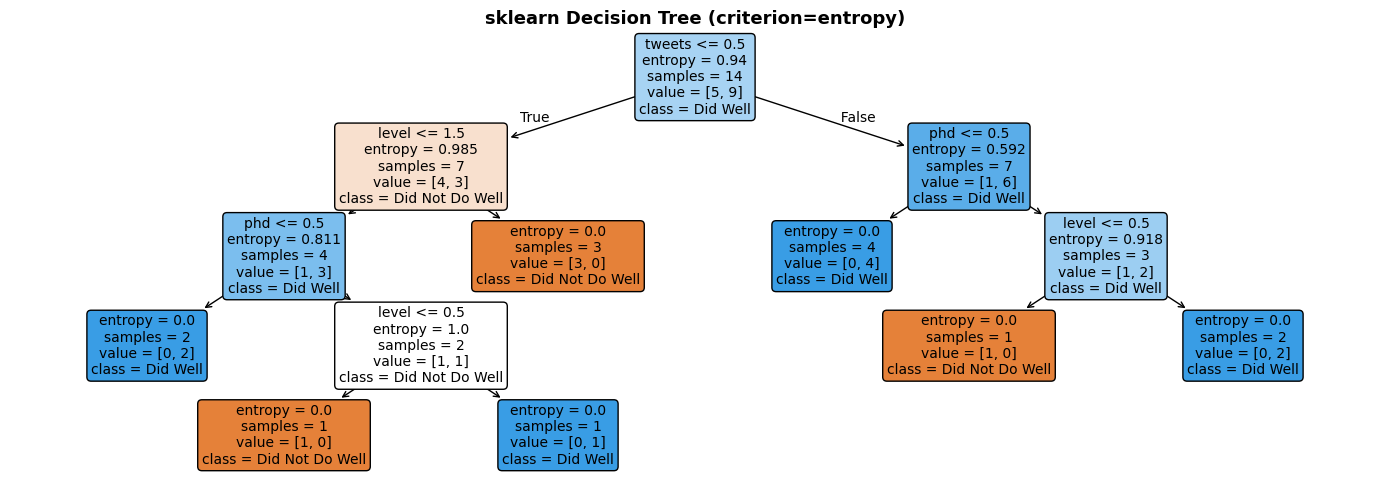

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(clf,
          feature_names=feature_names,
          class_names=['Did Not Do Well', 'Did Well'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title("sklearn Decision Tree (criterion=entropy)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

```
┌─────────────────────┐
│ tweets <= 0.5       │ ← Split condition (question asked)
│ entropy = 0.94      │ ← H of this node (uncertainty)
│ samples = 14        │ ← How many candidates here
│ value = [5, 9]      │ ← [Did Not Do Well, Did Well]
│ class = Did Well    │ ← Majority class at this node
└─────────────────────┘
```

## Color Meaning:
* Blue
  * Majority class = Did * Well
* Orange
  * Majority class = Did Not Do * Well
* White
  * Perfectly split — 50/50

# tweets is encoded as:
*  False = 0  → 0 <= 0.5 → True branch  (doesn't tweet)
* True  = 1  → 1 <= 0.5 → False branch (tweets)

# Bottom Line

Each box shows what question is asked, how uncertain the node is, how many samples are there, and what the majority prediction is. Follow True/False branches down until you reach a leaf node — that is your final prediction ✅

**Individual branches can have higher entropy than the parent — what matters is the weighted average always decreases.** That is what Information Gain measures ✅

### Feature Importance

Decision Trees and Random Forests naturally measure **how useful each feature is**
for making predictions.

**How it is calculated:**
For each feature, sum up the **information gain** it provides across all splits,
weighted by the number of samples at each node.

```
Feature Importance = Σ (weighted Information Gain from all splits using this feature)
                     normalized so all importances sum to 1.0
```

| Importance | Meaning |
|---|---|
| **Close to 1.0** | This feature drives most decisions |
| **Close to 0.0** | This feature contributes very little |
| **Sum = 1.0** | All importances always add up to 1 |

```python
# Access in sklearn:
clf.feature_importances_   # array of importances
```

> 💡 Random Forest feature importances are more **reliable** than single tree
> importances because they are averaged across many trees.


In [31]:
# Feature importances
importances = clf.feature_importances_
print("Feature importances (sklearn, entropy criterion):")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {name:8s}: {imp:.4f}  {bar}")

Feature importances (sklearn, entropy criterion):
  level   : 0.6386  █████████████████████████
  phd     : 0.1999  ███████
  tweets  : 0.1615  ██████
  lang    : 0.0000  


---
## 6.5 Train/Test Split — Evaluating Model Performance

Before we discuss overfitting, we need a way to **measure** it.
The solution is to split our data into two parts:

| Split | Purpose | Typical Size |
|---|---|---|
| **Training set** | Model learns from this | 70–80% |
| **Test set** | Evaluate on unseen data | 20–30% |

### Why This Matters

```
Without split:          With split:

All data → Model        Training data → Model
                        Test data     → Evaluate
                                          ↑
                               Model never saw this!
```

A model that scores **100% on training** but **60% on test** is overfitting —
it memorized the training data instead of learning general patterns.

### Key Rule
> ⚠️ **Never use test data during training.** The test set must remain completely
> unseen until final evaluation — otherwise your evaluation is meaningless.

### In sklearn
```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # reproducibility
)
```


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Simple demonstration of train/test split
X_demo, y_demo = make_classification(n_samples=100, n_features=4, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

print(f'Total samples  : {len(X_demo)}')
print(f'Training samples: {len(X_train)} ({len(X_train)/len(X_demo):.0%})')
print(f'Test samples    : {len(X_test)}  ({len(X_test)/len(X_demo):.0%})')
print()
print('Key rule: NEVER touch test data during training!')


Total samples  : 100
Training samples: 80 (80%)
Test samples    : 20  (20%)

Key rule: NEVER touch test data during training!


---
## 7. Overfitting and Pruning

A fully grown decision tree achieves 100% training accuracy — but at the cost of **memorizing noise**.

### Why Overfitting Happens

The ID3 algorithm keeps splitting until every leaf is pure. On a small dataset, this often means the tree has learned the training labels exactly, including any noise or coincidental patterns.

### Strategies to Reduce Overfitting

| Strategy | How | sklearn parameter |
|---|---|---|
| **Max depth** | Stop splitting after *k* levels | `max_depth=k` |
| **Min samples per leaf** | Only split if node has ≥ *n* points | `min_samples_leaf=n` |
| **Min samples to split** | Only split if node has ≥ *n* points | `min_samples_split=n` |
| **Cost-complexity pruning** | Remove subtrees that don't improve generalization | `ccp_alpha` |


### Bias-Variance Tradeoff

Overfitting is best understood through the **Bias-Variance Tradeoff**:

| Term | Meaning | Symptom |
|---|---|---|
| **Bias** | Model is too simple — misses patterns | High training error |
| **Variance** | Model is too complex — memorizes noise | Low train, high test error |
| **Sweet spot** | Generalizes well to new data | Low both |

```
Error
  ↑
  |  Bias (underfitting)      
  |  \                        
  |   \          Total Error  
  |    \        /             
  |     \      /              
  |      \    /  Variance (overfitting)
  |       \  /                
  |        \/                 
  |      Sweet spot           
  |__________________________ →  Model Complexity
  Simple                  Complex
  (shallow tree)          (deep tree)
```

**Decision trees** have **high variance** — small changes in data produce very
different trees. Random Forests fix this by **averaging many trees**.


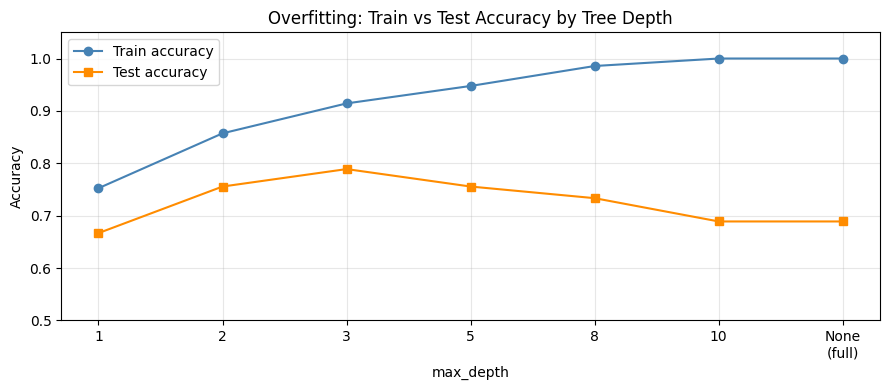


   max_depth  Train Accuracy  Test Accuracy
--------------------------------------------
           1           0.752          0.667
           2           0.857          0.756
           3           0.914          0.789
           5           0.948          0.756
           8           0.986          0.733
          10           1.000          0.689
 None
(full)           1.000          0.689


In [33]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset with noise
X_syn, y_syn = make_classification(n_samples=300, n_features=10,
                                   n_informative=5, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)

depths = [1, 2, 3, 5, 8, 10, None]
train_accs, test_accs = [], []

for d in depths:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_d.fit(X_tr, y_tr)
    train_accs.append(accuracy_score(y_tr, clf_d.predict(X_tr)))
    test_accs.append(accuracy_score(y_te, clf_d.predict(X_te)))

x_labels = [str(d) if d else 'None\n(full)' for d in depths]

plt.figure(figsize=(9, 4))
plt.plot(x_labels, train_accs, 'o-', label='Train accuracy', color='steelblue')
plt.plot(x_labels, test_accs,  's-', label='Test accuracy',  color='darkorange')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Overfitting: Train vs Test Accuracy by Tree Depth')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0.5, 1.05)
plt.tight_layout(); plt.show()

print("\n{:>12}  {:>14}  {:>13}".format('max_depth', 'Train Accuracy', 'Test Accuracy'))
print("-" * 44)
for d, tr, te in zip(x_labels, train_accs, test_accs):
    print(f"{str(d):>12}  {tr:>14.3f}  {te:>13.3f}")

---
## 7.5 Bootstrapping — The Foundation of Random Forests

**Bootstrapping** is a statistical technique of sampling **with replacement**
from your dataset to create new datasets of the same size.

**Why is is needed** Bootstrapping — By randomly sampling the data with replacement multiple times, you:

  * Create many different "versions" of your dataset
  * Introduce randomness that simulates the variability of real-world data
  * Get a distribution of results rather than a single estimate, which is far more informative

### How It Works

```
Original data: [A, B, C, D, E]   (5 samples)

Bootstrap sample 1: [A, A, C, D, B]  ← A appears twice, E missing
Bootstrap sample 2: [B, C, C, A, E]  ← C appears twice, D missing
Bootstrap sample 3: [E, A, B, B, D]  ← B appears twice, C missing
```

### Key Properties

| Property | Detail |
|---|---|
| **Same size** | Each bootstrap sample = same size as original |
| **With replacement** | Same sample can appear multiple times |
| **~63% unique** | On average, 63% of original samples appear |
| **~37% missing** | These become the **Out-of-Bag (OOB)** samples |

### Why 63%?
The probability a sample is **NOT** chosen in one draw = $(1 - 1/n)^n$
As $n \to \infty$, this approaches $e^{-1} \approx 0.368$

So ~36.8% are left out → ~63.2% are included.

> 💡 Those **left-out samples** are the OOB samples — and they give us a
> **free validation set** without needing a separate train/test split!


In [34]:
import random

# Simple bootstrapping demonstration
original = list('ABCDE')
n = len(original)

print(f'Original data: {original}')
print()

for i in range(3):
    sample = [random.choice(original) for _ in original]
    oob = [x for x in original if x not in sample]
    print(f'Bootstrap sample {i+1}: {sample}')
    print(f'OOB samples         : {oob}')
    print()

# Show ~63% rule
import numpy as np
trials = 10000
n_large = 1000
unique_pcts = []
for _ in range(trials):
    sample = np.random.choice(n_large, n_large, replace=True)
    unique_pcts.append(len(set(sample)) / n_large)

print(f'Average unique samples in bootstrap: {np.mean(unique_pcts):.1%}')
print(f'Average OOB samples                : {1-np.mean(unique_pcts):.1%}')


Original data: ['A', 'B', 'C', 'D', 'E']

Bootstrap sample 1: ['E', 'D', 'A', 'E', 'C']
OOB samples         : ['B']

Bootstrap sample 2: ['C', 'E', 'D', 'E', 'D']
OOB samples         : ['A', 'B']

Bootstrap sample 3: ['C', 'D', 'A', 'C', 'A']
OOB samples         : ['B', 'E']

Average unique samples in bootstrap: 63.2%
Average OOB samples                : 36.8%


---
## 7.6 Bagging — Bootstrap Aggregating

**Bagging** (Bootstrap AGGregating) uses bootstrapping to build
**many models** and combines their predictions:

```
Original Dataset
       |
  _____|_____
 |     |     |
BS1   BS2   BS3   ← Bootstrap samples
 |     |     |
T1    T2    T3    ← Train one tree on each
 |     |     |
  \    |    /
   VOTE / AVERAGE  ← Combine predictions
        |
   Final Prediction
```

### Why Bagging Reduces Variance

| Single Tree | Bagged Trees |
|---|---|
| High variance — sensitive to data | Low variance — errors cancel out |
| One perspective on data | Many perspectives on data |
| Can overfit easily | Much harder to overfit |

### Classification vs Regression

| Task | How to Combine |
|---|---|
| **Classification** | **Majority vote** across all trees |
| **Regression** | **Average** of all tree predictions |

> 💡 **Random Forests = Bagging + one extra trick:**
> at each split, only consider a **random subset of features**.
> This makes trees even more diverse and reduces correlation between them.


---
## 8. Random Forests — from Scratch

Random Forests address decision tree overfitting by building **many trees** and combining their votes. Two sources of randomness make each tree different:

### Randomness Source 1: Bootstrap Sampling (Bagging)

Each tree is trained on a **bootstrap sample** — a random sample *with replacement* of the same size as the training set. Roughly 63% of original points appear in each sample; the remaining ~37% form the **out-of-bag (OOB)** set, which can be used for free validation.

### Randomness Source 2: Feature Subsampling

At each split, only a **random subset of features** is considered. A common rule of thumb: $\sqrt{p}$ features for classification, $p/3$ for regression (where $p$ = total features).

### Why This Works

Each tree is a high-variance, low-bias learner (it can fit any pattern, but is sensitive to noise). By averaging many such trees:
- **Bias** stays low (trees are expressive)
- **Variance** drops (errors from noise cancel out across trees)

This is the **bias-variance tradeoff** in action.

In [35]:
import random

def bootstrap_sample(data: List[T]) -> List[T]:
    """Return a bootstrap sample (same size, with replacement)."""
    return [random.choice(data) for _ in data]

def build_random_tree(inputs: List[Any],
                      split_attributes: List[str],
                      target_attribute: str,
                      num_split_candidates: int) -> DecisionTree:
    """
    Like build_tree_id3 but at each split only considers a random
    subset of `num_split_candidates` attributes.
    """
    label_counts = Counter(getattr(inp, target_attribute) for inp in inputs)
    most_common_label = label_counts.most_common(1)[0][0]

    if len(label_counts) == 1:
        return Leaf(most_common_label)
    if not split_attributes:
        return Leaf(most_common_label)

    # --- KEY DIFFERENCE: sample attributes randomly ---
    if len(split_attributes) <= num_split_candidates:
        sampled_attrs = split_attributes
    else:
        sampled_attrs = random.sample(split_attributes, num_split_candidates)

    def split_entropy(attribute: str) -> float:
        return partition_entropy_by(inputs, attribute, target_attribute)

    best_attribute = min(sampled_attrs, key=split_entropy)
    partitions     = partition_by(inputs, best_attribute)
    new_attributes = [a for a in split_attributes if a != best_attribute]

    subtrees = {
        attr_value: build_random_tree(subset, new_attributes,
                                       target_attribute, num_split_candidates)
        for attr_value, subset in partitions.items()
    }

    return Split(best_attribute, subtrees, default_value=most_common_label)


def random_forest_predict(forest: List[DecisionTree], input: Any) -> Any:
    """Majority vote from all trees in the forest."""
    votes = [classify(tree, input) for tree in forest]
    return Counter(votes).most_common(1)[0][0]


def build_random_forest(inputs: List[Any],
                        split_attributes: List[str],
                        target_attribute: str,
                        n_trees: int = 20,
                        num_split_candidates: int = 2,
                        seed: int = 42) -> List[DecisionTree]:
    """Build a random forest using bagging + random feature subsets."""
    random.seed(seed)
    forest = []
    for _ in range(n_trees):
        sample = bootstrap_sample(inputs)          # bagging
        tree   = build_random_tree(sample,
                                   split_attributes,
                                   target_attribute,
                                   num_split_candidates)
        forest.append(tree)
    return forest


# Build and evaluate
attributes = ['level', 'lang', 'tweets', 'phd']
forest = build_random_forest(inputs, attributes, 'did_well',
                              n_trees=50, num_split_candidates=2)

print(f"Forest has {len(forest)} trees")
correct = sum(1 for inp in inputs
              if random_forest_predict(forest, inp) == inp.did_well)
print(f"Forest training accuracy: {correct}/{len(inputs)} = {correct/len(inputs):.0%}")

# Show individual tree votes for a candidate
test_candidate = Candidate('Senior', 'Python', True, False)
votes = [classify(t, test_candidate) for t in forest]
vote_counts = Counter(votes)
print(f"\nVotes for {test_candidate}: {dict(vote_counts)}")
print(f"Forest prediction: {random_forest_predict(forest, test_candidate)}")

Forest has 50 trees
Forest training accuracy: 14/14 = 100%

Votes for Candidate(level='Senior', lang='Python', tweets=True, phd=False, did_well=None): {True: 40, False: 10}
Forest prediction: True


### Out-of-Bag (OOB) Score

Because each tree is trained on a bootstrap sample, roughly **37% of samples**
are left out of each tree. These **Out-of-Bag** samples act as a built-in
validation set:

```
Tree 1 trained on [A,A,C,D,B] → validate on E
Tree 2 trained on [B,C,C,A,E] → validate on D
Tree 3 trained on [E,A,B,B,D] → validate on C

Each sample gets predicted ONLY by trees that never saw it!
→ OOB Score = accuracy of these predictions
```

| OOB Score | Advantage |
|---|---|
| Free validation | No separate test set needed |
| Unbiased estimate | Each prediction from unseen trees |
| Close to CV | Often close to k-fold cross-validation |

```python
# Enable OOB scoring in sklearn:
rf = RandomForestClassifier(oob_score=True)
rf.fit(X, y)
print(rf.oob_score_)  # free accuracy estimate!
```


### Key Random Forest Hyperparameters

| Parameter | What It Controls | Typical Value |
|---|---|---|
| **n_estimators** | Number of trees | 100–500 |
| **max_features** | Features considered per split | `sqrt(n)` for classification |
| **max_depth** | Maximum depth of each tree | None (fully grown) |
| **min_samples_split** | Min samples to split a node | 2 |
| **oob_score** | Use OOB for validation | True |

### n_estimators — More Trees = Better (up to a point)

```
Accuracy
  ↑
  |          plateau ←――――――――――
  |      /‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
  |    /
  |  /
  | /
  |/_________________________ →  n_estimators
  1   10   50  100  200  500
```
Gains plateau around **50–100 trees** — more trees cost compute but don't help much.

### max_features — The Key Random Forest Trick

```
Decision Tree:    considers ALL features at each split
Random Forest:    considers only sqrt(n_features) at each split
                                  ↑
                    Forces diversity between trees!
```

| max_features | Effect |
|---|---|
| `'sqrt'` | Standard for classification ✅ |
| `'log2'` | More aggressive reduction |
| `None` | All features — becomes pure bagging |
| `1` | Maximum diversity — slowest learning |


---
## 9. Random Forests with scikit-learn

sklearn's `RandomForestClassifier` is production-grade: it supports parallelism, OOB scoring, feature importances, and many more tunable hyperparameters.

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Re-use the encoded X, y from earlier
rf = RandomForestClassifier(n_estimators=100,
                             criterion='entropy',
                             max_features='sqrt',      # sqrt(p) per split
                             oob_score=True,           # use OOB samples as validation
                             random_state=42)
rf.fit(X, y)

print(f"RF training accuracy : {rf.score(X, y):.0%}")
print(f"RF OOB score (≈ test): {rf.oob_score_:.2%}")
print()

# Feature importances
print("Feature importances (Random Forest):")
for name, imp in sorted(zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {name:8s}: {imp:.4f}  {bar}")

RF training accuracy : 100%
RF OOB score (≈ test): 78.57%

Feature importances (Random Forest):
  level   : 0.4248  ████████████████
  tweets  : 0.2267  █████████
  phd     : 0.2086  ████████
  lang    : 0.1399  █████


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


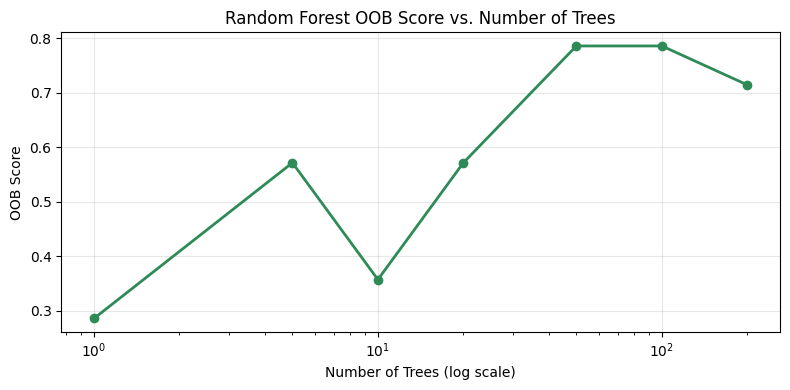

More trees generally helps — but returns diminish quickly after ~50-100.


In [37]:
# Show how OOB score improves as we add more trees
n_trees_range = [1, 5, 10, 20, 50, 100, 200]
oob_scores = []

for n in n_trees_range:
    rf_n = RandomForestClassifier(n_estimators=n, criterion='entropy',
                                   oob_score=True, random_state=42)
    rf_n.fit(X, y)
    oob_scores.append(rf_n.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_trees_range, oob_scores, 'o-', color='seagreen', lw=2)
plt.xscale('log')
plt.xlabel('Number of Trees (log scale)')
plt.ylabel('OOB Score')
plt.title('Random Forest OOB Score vs. Number of Trees')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("More trees generally helps — but returns diminish quickly after ~50-100.")

### MSE as the Splitting Criterion for Regression Trees

For regression trees, we cannot use entropy (which needs class labels).
Instead we minimize **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

where $\bar{y}$ is the mean of the target values in the node.

### Comparison: Classification vs Regression Trees

| Aspect | Classification Tree | Regression Tree |
|---|---|---|
| **Output** | Class label | Continuous value |
| **Split criterion** | Entropy / Gini | MSE |
| **Leaf prediction** | Majority class | Mean of values |
| **Evaluation** | Accuracy | MSE / RMSE |

### How MSE Split Works

```
Node: [10, 12, 11, 50, 48, 52]   mean=30.5   MSE=high

Split on threshold:
Left:  [10, 12, 11]  mean=11   MSE=0.67  ← very pure!
Right: [50, 48, 52]  mean=50   MSE=2.67  ← very pure!

Weighted MSE after split = much lower → good split!
```

> 💡 Just like Information Gain measures entropy reduction,
> regression trees measure **MSE reduction** at each split.


---
## 10. Regression Trees (ISLP Examples)

So far we've focused on **classification** trees (categorical output). **Regression** trees predict a **continuous** value. Instead of entropy, they minimize **MSE (Mean Squared Error)** within each leaf.

### Splitting Rule for Regression

At each node, find the feature $j$ and threshold $t$ that minimize:
$$\text{MSE}_{split} = \frac{n_L}{n} \cdot \text{MSE}(S_L) + \frac{n_R}{n} \cdot \text{MSE}(S_R)$$

The prediction at a leaf is the **mean** of training values that fell into that leaf.

We use the `Hitters` dataset from ISLP (from *Introduction to Statistical Learning*) — predicting baseball player salary from performance statistics.

In [38]:
from ISLP import load_data
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Load Hitters dataset
Hitters = load_data('Hitters')
Hitters = Hitters.dropna()   # remove rows with missing salary
Hitters['LogSalary'] = np.log(Hitters['Salary'])

print(f"Dataset shape: {Hitters.shape}")
print(f"Target (LogSalary): mean={Hitters.LogSalary.mean():.2f}, std={Hitters.LogSalary.std():.2f}")
print("\nFirst 3 rows (selected columns):")
print(Hitters[['Years', 'Hits', 'RBI', 'Salary', 'LogSalary']].head(3).to_string(index=False))

Dataset shape: (263, 21)
Target (LogSalary): mean=5.93, std=0.89

First 3 rows (selected columns):
 Years  Hits  RBI  Salary  LogSalary
    14    81   38   475.0   6.163315
     3   130   72   480.0   6.173786
    11   141   78   500.0   6.214608


Regression Tree (max_depth=3)
  Train MSE: 0.1279
  Test  MSE: 0.4454


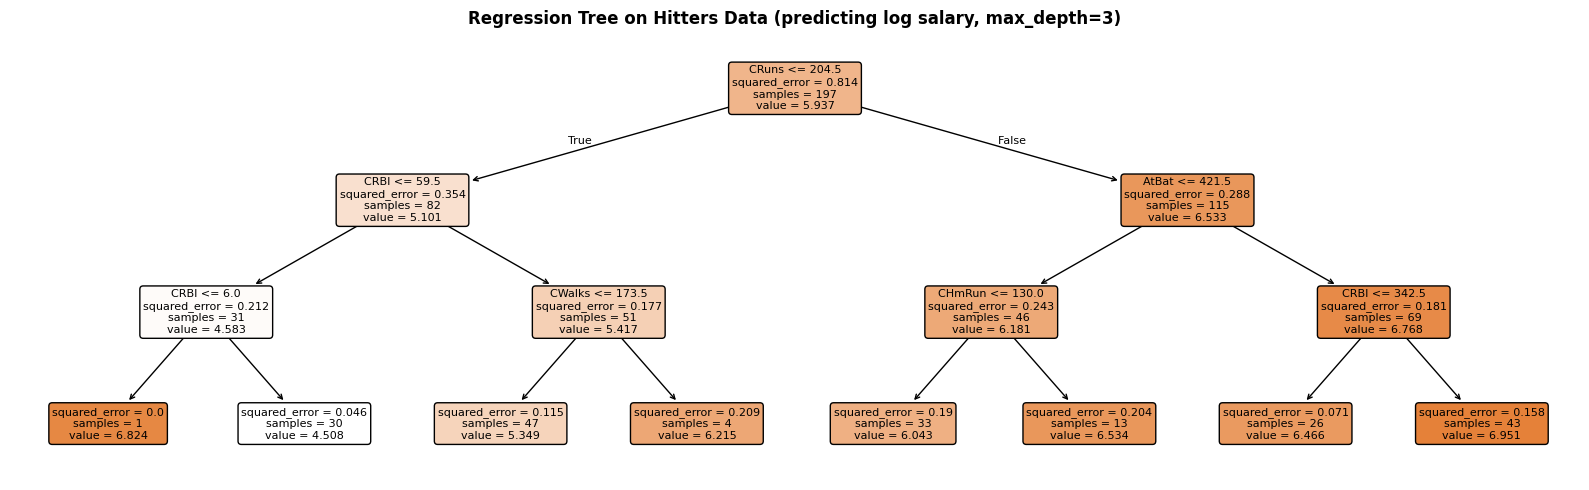

In [39]:
# Prepare features (drop categorical and target columns)
cat_cols = Hitters.select_dtypes(include='category').columns
X_h = pd.get_dummies(Hitters.drop(columns=['Salary', 'LogSalary']), drop_first=True)
y_h = Hitters['LogSalary']

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_h, y_h, test_size=0.25, random_state=42)

# Regression tree
rt = DecisionTreeRegressor(max_depth=3, random_state=42)
rt.fit(X_tr_h, y_tr_h)

from sklearn.metrics import mean_squared_error
train_mse = mean_squared_error(y_tr_h, rt.predict(X_tr_h))
test_mse  = mean_squared_error(y_te_h, rt.predict(X_te_h))

print(f"Regression Tree (max_depth=3)")
print(f"  Train MSE: {train_mse:.4f}")
print(f"  Test  MSE: {test_mse:.4f}")

# Visualize the tree
fig, ax = plt.subplots(figsize=(16, 5))
plot_tree(rt,
          feature_names=X_h.columns.tolist(),
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Regression Tree on Hitters Data (predicting log salary, max_depth=3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Random Forest Regressor (500 trees)
  Test MSE: 0.2561  (vs single tree: 0.4454)


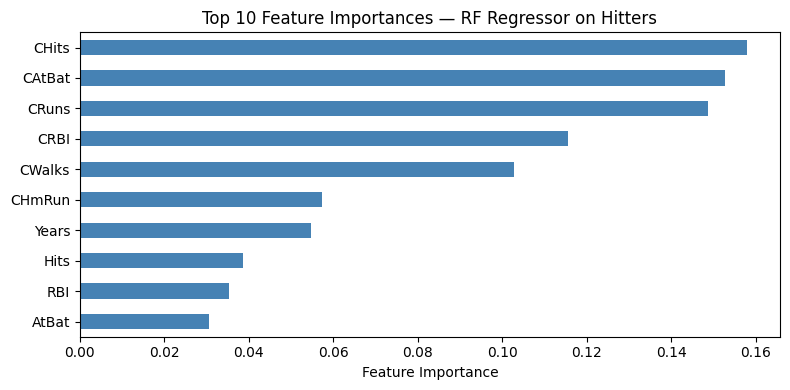

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=500, max_features='sqrt',
                                oob_score=True, random_state=42)
rf_reg.fit(X_tr_h, y_tr_h)

rf_test_mse = mean_squared_error(y_te_h, rf_reg.predict(X_te_h))
print(f"Random Forest Regressor (500 trees)")
print(f"  Test MSE: {rf_test_mse:.4f}  (vs single tree: {test_mse:.4f})")

# Top feature importances
feat_imp = pd.Series(rf_reg.feature_importances_, index=X_h.columns)
top10 = feat_imp.nlargest(10)

plt.figure(figsize=(8, 4))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances — RF Regressor on Hitters')
plt.tight_layout()
plt.show()

---
## 📝 Summary

| Concept | Key Takeaway |
|---|---|
| **Entropy** | Measures uncertainty; 0 = pure, 1 = max for binary |
| **Information Gain** | How much a split reduces entropy — the ID3 splitting criterion |
| **ID3 Algorithm** | Greedy, top-down tree building; fast but may overfit |
| **Overfitting** | Fully grown trees memorize noise; use `max_depth`, pruning, or ensembles |
| **Gini vs Entropy** | Both measure impurity; Gini is faster, results are usually similar |
| **Bagging** | Bootstrap samples → multiple trees → average/vote reduces variance |
| **Random Forest** | Bagging + random feature subsets = more diverse trees, better generalization |
| **Regression Trees** | Same idea, but split on MSE; leaf prediction = mean of contained values |

---

### Further Reading
- [sklearn Decision Trees documentation](https://scikit-learn.org/stable/modules/tree.html)
- [sklearn Random Forest documentation](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)
- *Introduction to Statistical Learning* (ISLP) — Chapter 8
- *Data Science from Scratch* — Chapter 17

---

## Common Student Questions

This section addresses questions that frequently come up after working through this notebook. Each answer connects directly to the code and concepts you have already seen above.


---

### Q1: How should I split data into train and test sets?

The standard rule of thumb is **80% train / 20% test** for most datasets. Three things to always remember:

- Always set `random_state` so your results are reproducible. Without it the split changes every run.
- Always use `stratify=y` when your classes are imbalanced. Otherwise the test set might accidentally contain very few examples of the minority class.
- For very small datasets (fewer than ~100 rows, like the 15-row hiring data in this notebook), a train/test split is unreliable. Use cross-validation or OOB score instead.


In [41]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% held out for testing
    random_state=42,  # reproducible
    stratify=y        # preserves class balance in both splits
)

print(f'Train size : {len(X_train)} rows')
print(f'Test size  : {len(X_test)} rows')
train_vals, train_counts = np.unique(y_train, return_counts=True)
test_vals,  test_counts  = np.unique(y_test,  return_counts=True)
print(f'Train class balance: {dict(zip(train_vals, train_counts))}')
print(f'Test  class balance: {dict(zip(test_vals,  test_counts))}')


Train size : 11 rows
Test size  : 3 rows
Train class balance: {np.int64(0): np.int64(4), np.int64(1): np.int64(7)}
Test  class balance: {np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


---

### Q2: Why did ID3 split on `level` first, but sklearn split on `tweets`?

Both answers are correct — they are solving slightly different problems. Three reasons explain the difference:

**Reason 1 — Split strategy (the main reason)**

ID3 is a multi-way splitter. When it picks `level` it creates three branches at once: Junior, Mid, and Senior, getting full credit for the fact that the Mid branch is perfectly pure. sklearn uses **CART**, which is binary only. CART cannot do a 3-way split. It must frame `level` as a binary question such as `level == Senior vs not`, which is a weaker cut. `tweets` is a natural True/False feature that CART can exploit fully, so it wins.

**Reason 2 — How information gain is calculated**

ID3 scores each feature by its overall partition entropy across all its values at once. CART scores every possible binary threshold for every feature and picks the single best binary cut. These are different calculations and can rank features differently even on identical data and the same entropy formula:

```
ID3  scores level as one 3-way split  -> 0.69   <- level wins
CART scores best binary cut of level  -> 0.74
CART scores best binary cut of tweets -> 0.63   <- tweets wins
```

**Reason 3 — Dataset size**

With only 15 rows, tiny differences in how gain is computed can flip the winning feature. Both trees are working correctly.

> **Key takeaway:** sklearn's `DecisionTreeClassifier` always uses CART regardless of which `criterion` you set. Setting `criterion='entropy'` only changes how impurity is measured, not the binary-split-only structure of the algorithm. The difference in first split here is driven by multi-way vs binary splitting, not the impurity measure.


In [42]:
# Confirm: sklearn always uses CART (binary splits only)
# The criterion parameter only controls the impurity measure, not the algorithm
from sklearn.tree import DecisionTreeClassifier, export_text

clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_gini    = DecisionTreeClassifier(criterion='gini',    random_state=42)

clf_entropy.fit(X, y)
clf_gini.fit(X, y)

feature_names = ['level', 'lang', 'tweets', 'phd']

print('=== sklearn with entropy ===')
print(export_text(clf_entropy, feature_names=feature_names))

print('=== sklearn with gini ===')
print(export_text(clf_gini, feature_names=feature_names))

print('Both are CART: binary splits only, regardless of criterion.')


=== sklearn with entropy ===
|--- tweets <= 0.50
|   |--- level <= 1.50
|   |   |--- phd <= 0.50
|   |   |   |--- class: 1
|   |   |--- phd >  0.50
|   |   |   |--- level <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- level >  0.50
|   |   |   |   |--- class: 1
|   |--- level >  1.50
|   |   |--- class: 0
|--- tweets >  0.50
|   |--- phd <= 0.50
|   |   |--- class: 1
|   |--- phd >  0.50
|   |   |--- level <= 0.50
|   |   |   |--- class: 0
|   |   |--- level >  0.50
|   |   |   |--- class: 1

=== sklearn with gini ===
|--- tweets <= 0.50
|   |--- level <= 1.50
|   |   |--- phd <= 0.50
|   |   |   |--- class: 1
|   |   |--- phd >  0.50
|   |   |   |--- level <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- level >  0.50
|   |   |   |   |--- class: 1
|   |--- level >  1.50
|   |   |--- class: 0
|--- tweets >  0.50
|   |--- phd <= 0.50
|   |   |--- class: 1
|   |--- phd >  0.50
|   |   |--- level <= 0.50
|   |   |   |--- class: 0
|   |   |--- level >  0.50
|   |   |   |--- c

---

### Q3: Why does a fully grown decision tree always get 100% training accuracy?

Because it **memorizes** the training data rather than learning from it. A tree allowed to grow without limits keeps splitting until every leaf contains exactly one class. At that point it has essentially stored every training example as a rule. It will predict training data perfectly but fail on new data it has never seen.

This is **overfitting**: low bias (fits training data perfectly) but very high variance (predictions change dramatically if you swap in different training data).

The fixes are:

- **Pruning** — limit `max_depth`, `min_samples_leaf`, or `min_samples_split`
- **Random Forest** — average many trees to reduce variance without sacrificing accuracy


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

depths = [None, 1, 2, 3]
print(f"{'max_depth':<12} {'Train acc':>10} {'CV acc (5-fold)':>16}")
print('-' * 42)

for d in depths:
    clf_d = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf_d.fit(X, y)
    train_acc = clf_d.score(X, y)
    cv_acc = cross_val_score(clf_d, X, y, cv=5).mean()
    label = 'unlimited' if d is None else str(d)
    print(f"{label:<12} {train_acc:>10.0%} {cv_acc:>16.0%}")

print()
print('Notice: unlimited depth = 100% train accuracy, but CV accuracy is lower.')
print('Pruning (max_depth) trades some training accuracy for better generalization.')


max_depth     Train acc  CV acc (5-fold)
------------------------------------------
unlimited          100%              57%
1                   71%              40%
2                   86%              40%
3                   93%              40%

Notice: unlimited depth = 100% train accuracy, but CV accuracy is lower.
Pruning (max_depth) trades some training accuracy for better generalization.


---

### Q4: When should I use a decision tree vs a random forest?

| Situation | Use |
|---|---|
| You need to **explain** every decision to a non-technical audience | Decision Tree |
| You need the best possible **predictive accuracy** | Random Forest |
| Your dataset is **very small** (fewer than 100 rows) | Decision Tree |
| You have **many features** and are not sure which matter | Random Forest |
| You need a **fast baseline** to understand your data | Decision Tree |
| You are building a **production model** | Random Forest |

A common workflow is to start with a single decision tree to understand the problem structure, then switch to a Random Forest when you need better accuracy.


---

### Q5: What is the difference between bias and variance?

Think of throwing darts at a bullseye:

- **High bias** — darts consistently land in the wrong spot. Your model has made wrong assumptions about the data and is systematically off regardless of which training data you give it. Also called **underfitting**.
- **High variance** — darts are scattered all over. Your model is too sensitive to the specific training data it saw. Change the training data slightly and the model changes dramatically. Also called **overfitting**.

| Model | Bias | Variance |
|---|---|---|
| Very deep decision tree | Low | High — memorizes training data |
| Very shallow decision tree | High | Low — too simple to capture patterns |
| Random Forest | Low | Much lower — averaging trees reduces wobble |

The goal is low bias **and** low variance. In practice there is always a tradeoff. Random Forests are effective precisely because bagging reduces variance while keeping bias low.


---

### Q6: What is Out-of-Bag (OOB) score and why is it useful?

When building each tree in a Random Forest, roughly **37% of training rows are not selected** in that tree's bootstrap sample. These left-out rows are called **Out-of-Bag (OOB) samples**.

Since each tree never trained on its OOB rows, those rows act as a free validation set. For each training row, predictions are collected only from trees that did not train on it, then a majority vote is taken. Comparing those predictions to the true labels gives the **OOB score** — an honest estimate of how well the model generalizes to unseen data.

The practical benefit: you get a reliable accuracy estimate **without setting aside a separate test set**. For small datasets where you cannot afford to lose 20% of your data, OOB score is especially valuable.


In [44]:
from sklearn.ensemble import RandomForestClassifier

n_trees_range = [1, 5, 10, 20, 50, 100, 200]

print(f"{'n_estimators':<15} {'OOB Score':>10}")
print('-' * 28)

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X, y)
    print(f"{n:<15} {rf.oob_score_:>10.0%}")

print()
print('OOB score stabilizes as more trees are added.')
print('This is a free accuracy estimate: no separate test set needed.')


n_estimators     OOB Score
----------------------------
1                      29%
5                      57%


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


10                     36%
20                     64%
50                     79%
100                    79%
200                    71%

OOB score stabilizes as more trees are added.
This is a free accuracy estimate: no separate test set needed.


---

### Q7: Why does ID3 use a greedy approach instead of finding the globally optimal tree?

Finding the globally optimal decision tree is an **NP-hard** problem. The number of possible trees grows exponentially with the number of features and rows. Even for a modest dataset, exhaustively evaluating every possible tree is computationally infeasible.

ID3 and CART both use a **greedy strategy** instead: at each node, pick the single best split available right now and never revisit that decision. This does not guarantee the globally optimal tree, but it is fast and produces good results in practice.

Random Forests compensate for the limitations of any single greedy tree by building many of them and averaging their predictions, turning a weakness into a strength.

---
